**TASK 6 DATA CLEANING AND EDA**

In [2]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
with open("India-Food-Delivery-Time-Prediction.txt") as f:
    data=json.load(f)
df=pd.DataFrame(data)

In [4]:
columns=df.select_dtypes(include='object').columns
for i in columns:
    df[i]=df[i].str.strip()


In [5]:
df=df.replace('NaN',pd.NA)

In [6]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
dtype: int64

In [7]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [8]:
df["Delivery_person_Age"]=pd.to_numeric(df["Delivery_person_Age"],errors="coerce")
df["Delivery_person_Ratings"]=pd.to_numeric(df["Delivery_person_Ratings"],errors="coerce")
df["multiple_deliveries"]=pd.to_numeric(df["multiple_deliveries"],errors="coerce")
df["Order_Date"]=pd.to_datetime(df["Order_Date"],format="%d-%m-%Y",errors="coerce")
df["Time_orderd"]=pd.to_datetime(df["Time_Orderd"],format="%H:%M:%S",errors="coerce").dt.time
df["Time_order_picked"]=pd.to_datetime(df["Time_Order_picked"],format="%H:%M:%S",errors="coerce").dt.time

KeyboardInterrupt: 

In [ ]:
df["Weatherconditions"]=df["Weatherconditions"].str.replace("conditions ",'',regex=False)
df["Weatherconditions"]=df["Weatherconditions"].replace('NaN',pd.NA)

In [ ]:
df["Time_taken(min)"]=df["Time_taken(min)"].str.extract("(\d+)").astype(int)

In [ ]:
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                        215
City                           1114
Time_taken(min)                   0
Time_orderd                    1600
Time_order_picked                 0
dtype: int64

In [ ]:
df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median(),inplace=True)
df["Delivery_person_Ratings"].fillna(df["Delivery_person_Age"].median(),inplace=True)
df["multiple_deliveries"].fillna(0,inplace=True)
df.dropna(subset=["Weatherconditions","Road_traffic_density","City"],inplace=True)
df.dropna(subset=["Time_orderd"],inplace=True)
df.dropna(subset=["Festival"],inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21252\1620128468.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median(),inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21252\1620128468.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [ ]:
df.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
Time_orderd                    0
Time_order_picked              0
dtype: int64

In [ ]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken(min)                  int64
Time_orderd                     object
Time_order_picked               object
dtype: object

In [ ]:
print((df["Delivery_person_Ratings"]>5).sum())

0


In [ ]:
df.loc[df["Delivery_person_Ratings"]>5,"Delivery_person_Ratings"]=pd.NA
df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median(),inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21252\3730480472.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median(),inplace=True)


In [ ]:
df.to_csv('India_Food_Delivery_Cleaned.csv', index=False)

**Exploratory Data Analysis**

In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,39105.000000,39105.000000,39105.000000,39105.000000,39105.000000,39105.000000,39105.000000,39105.000000,39105.000000
mean,29.597264,4.783723,18.922283,76.921448,18.986094,76.985258,0.996420,0.733436,26.499169
std,5.747848,1.977613,5.465290,3.507254,5.467133,3.507444,0.817157,0.576523,9.333261
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.986047,73.897902,13.066279,73.939315,0.000000,0.000000,19.000000
50%,30.000000,4.700000,19.065838,76.618203,19.125831,76.662278,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.751234,78.368855,22.821226,78.405883,2.000000,1.000000,33.000000
max,39.000000,30.000000,30.914057,88.433452,31.054057,88.563452,2.000000,3.000000,54.000000


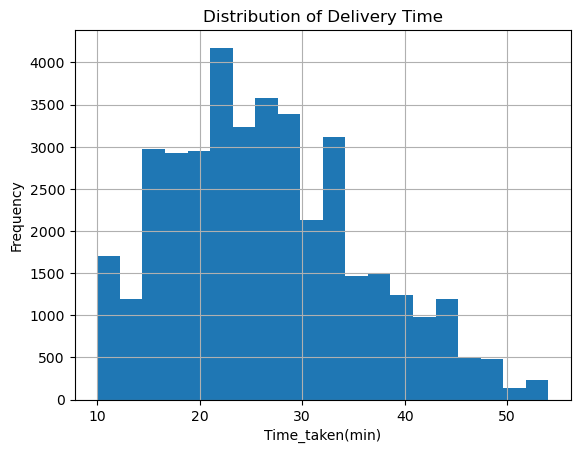

In [ ]:
import matplotlib.pyplot as plt
df["Time_taken(min)"].hist(bins=20)
plt.xlabel("Time_taken(min)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")
plt.show()


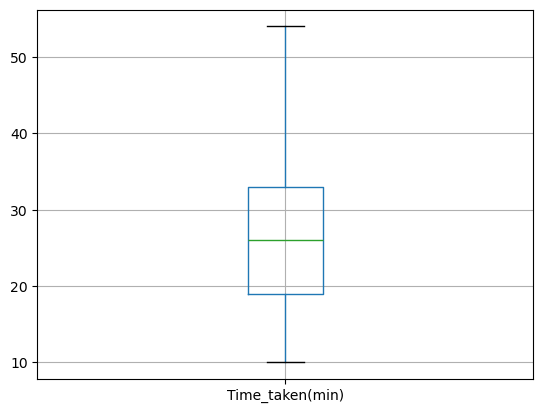

In [ ]:
df.boxplot(column="Time_taken(min)")
plt.show()

In [ ]:
print(df["Weatherconditions"].value_counts())
print(df["Road_traffic_density"].value_counts())
print(df["City"].value_counts())

Weatherconditions
Fog           6683
Stormy        6593
Cloudy        6579
Sandstorms    6498
Windy         6456
Sunny         6296
Name: count, dtype: int64
Road_traffic_density
Low       13233
Jam       12434
Medium     9569
High       3869
Name: count, dtype: int64
City
Metropolitian    30121
Urban             8843
Semi-Urban         141
Name: count, dtype: int64


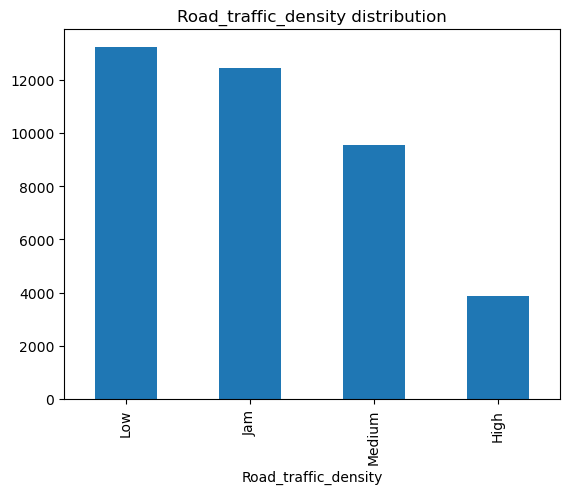

In [ ]:
df["Road_traffic_density"].value_counts().plot(kind="bar")
plt.title("Road_traffic_density distribution")
plt.show()

Road_traffic_density
Low       21.443890
Medium    26.876372
High      27.332644
Jam       31.329661
Name: Time_taken(min), dtype: float64


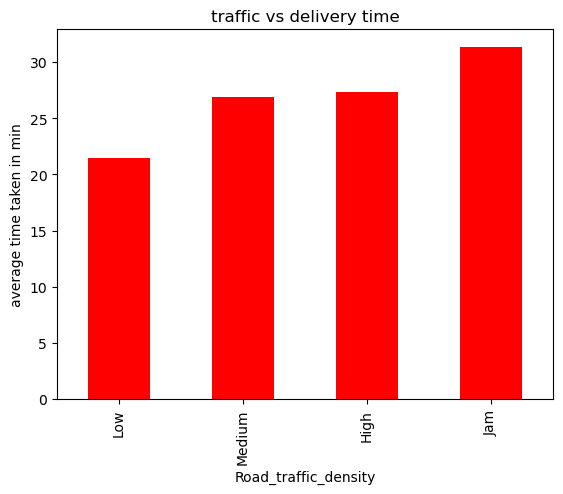

In [ ]:
print(df.groupby("Road_traffic_density")["Time_taken(min)"].mean().sort_values())
df.groupby("Road_traffic_density")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="red")
plt.ylabel("average time taken in min")
plt.title("traffic vs delivery time")
plt.show()

Weatherconditions
Sunny         22.094981
Sandstorms    26.068483
Stormy        26.077658
Windy         26.295849
Cloudy        29.079191
Fog           29.139458
Name: Time_taken(min), dtype: float64


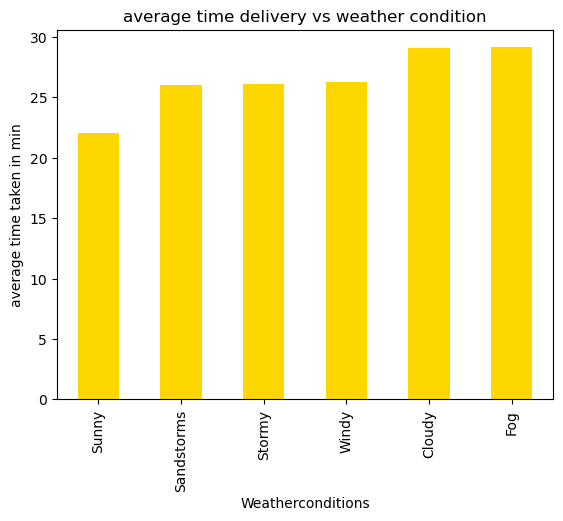

In [ ]:
print(df.groupby("Weatherconditions")["Time_taken(min)"].mean().sort_values())
df.groupby("Weatherconditions")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="gold")
plt.ylabel("average time taken in min")
plt.title("average time delivery vs weather condition")
plt.show()

Type_of_vehicle
electric_scooter    24.554841
scooter             24.706974
motorcycle          27.774126
Name: Time_taken(min), dtype: float64


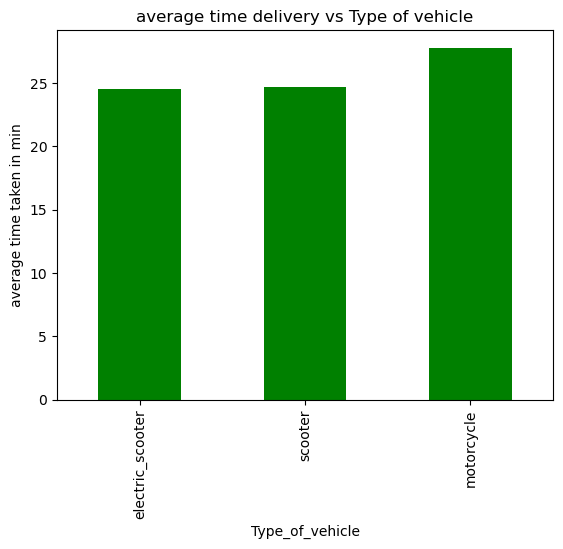

In [ ]:
print(df.groupby("Type_of_vehicle")["Time_taken(min)"].mean().sort_values())
df.groupby("Type_of_vehicle")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="green")
plt.ylabel("average time taken in min")
plt.title("average time delivery vs Type of vehicle")
plt.show()

City
Urban            23.163067
Metropolitian    27.370074
Semi-Urban       49.680851
Name: Time_taken(min), dtype: float64


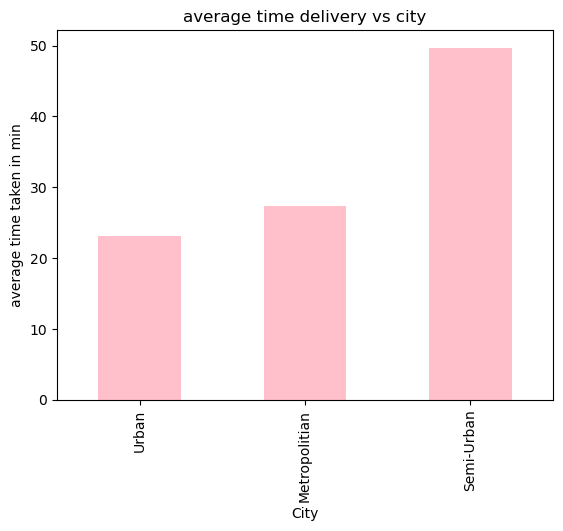

In [ ]:
print(df.groupby("City")["Time_taken(min)"].mean().sort_values())
df.groupby("City")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="pink")
plt.ylabel("average time taken in min")
plt.title("average time delivery vs city")
plt.show()

Festival
No     26.114975
Yes    45.500645
Name: Time_taken(min), dtype: float64


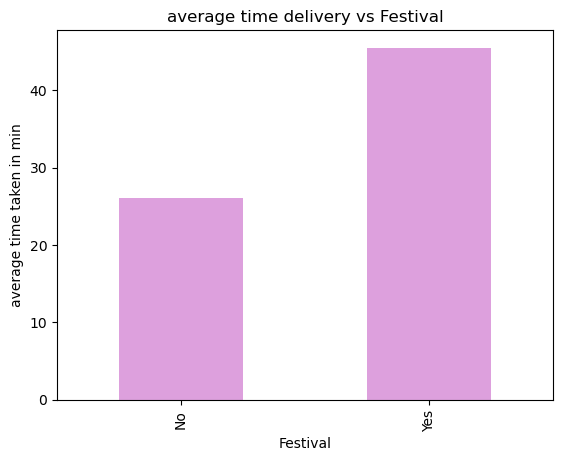

In [ ]:
print(df.groupby("Festival")["Time_taken(min)"].mean().sort_values())
df.groupby("Festival")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="plum")
plt.ylabel("average time taken in min")
plt.title("average time delivery vs Festival")
plt.show()

multiple_deliveries
0.0    23.123583
1.0    26.998763
2.0    40.461538
3.0    47.882736
Name: Time_taken(min), dtype: float64


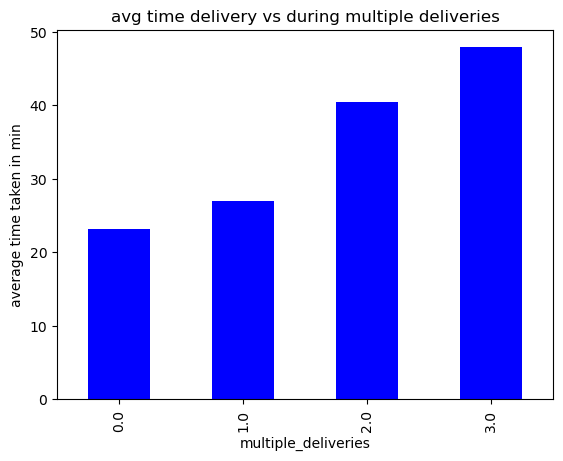

In [ ]:
print(df.groupby("multiple_deliveries")["Time_taken(min)"].mean().sort_values())
df.groupby("multiple_deliveries")["Time_taken(min)"].mean().sort_values().plot(kind="bar",color="blue")
plt.ylabel("average time taken in min")
plt.title("avg time delivery vs during multiple deliveries")
plt.show()

In [ ]:
df[["Delivery_person_Age","Delivery_person_Ratings","Time_taken(min)"]].corr()

,Delivery_person_Age,Delivery_person_Ratings,Time_taken(min)
Delivery_person_Age,1.000000,-0.017395,0.296651
Delivery_person_Ratings,-0.017395,1.000000,-0.057054
Time_taken(min),0.296651,-0.057054,1.000000


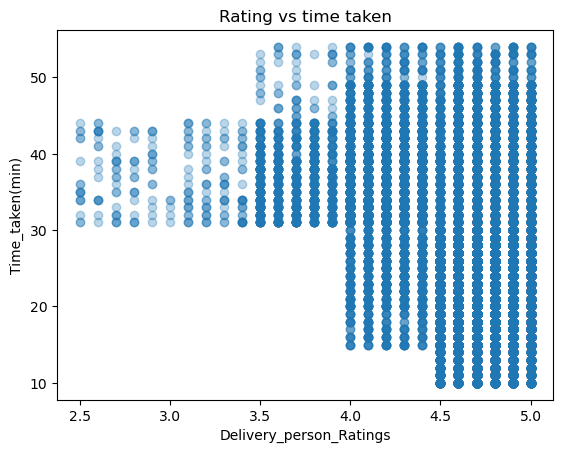

In [ ]:
plt.scatter(df["Delivery_person_Ratings"],df["Time_taken(min)"],alpha=0.3)
plt.xlabel("Delivery_person_Ratings")
plt.ylabel("Time_taken(min)")
plt.title("Rating vs time taken")
plt.show()

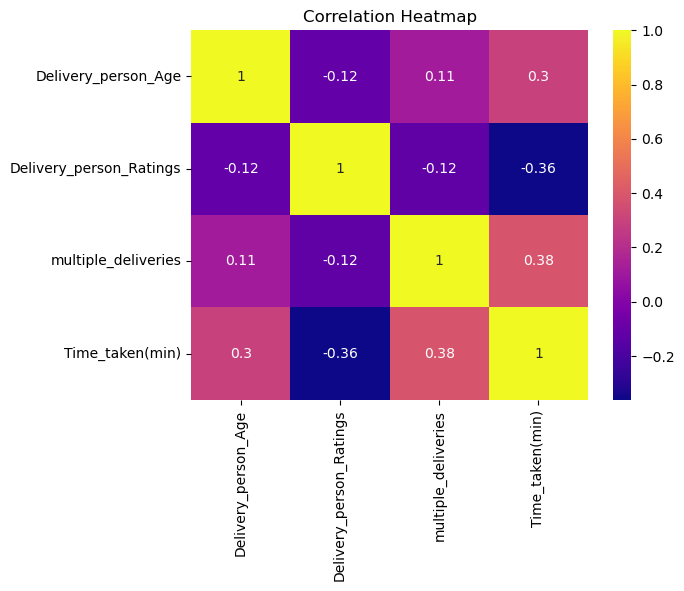

In [ ]:
numeric_df= df[["Delivery_person_Age","Delivery_person_Ratings","multiple_deliveries","Time_taken(min)"]]
sns.heatmap(numeric_df.corr(), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df["Order_Date"].dt.day_name().value_counts()

Order_Date
Wednesday    6131
Friday       5968
Tuesday      5485
Thursday     5448
Saturday     5401
Sunday       5346
Monday       5326
Name: count, dtype: int64

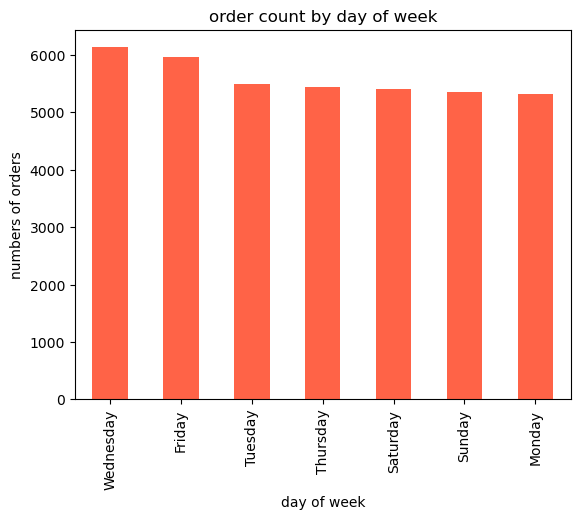

In [ ]:
df["Order_Date"].dt.day_name().value_counts().plot(kind="bar",color="tomato")
plt.xlabel("day of week")
plt.ylabel("numbers of orders")
plt.title("order count by day of week")
plt.show()